        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
Polynomial degree: 1
Training RMSE: 62.08
Testing RMSE: 63.73
Training R²: 0.37
Testing R²: 0.23
Polynomial degree: 2
Training RMSE: 62.04
Testing RMSE: 63.91
Training R²: 0.37
Testing R²: 0.23
Polynomial degree: 3
Training RMSE: 62.04
Testing RMSE: 63.75
Training R²: 0.37
Testing R²: 0.23
Polynomial degree: 5
Training RMSE: 61.84
Testing RMSE

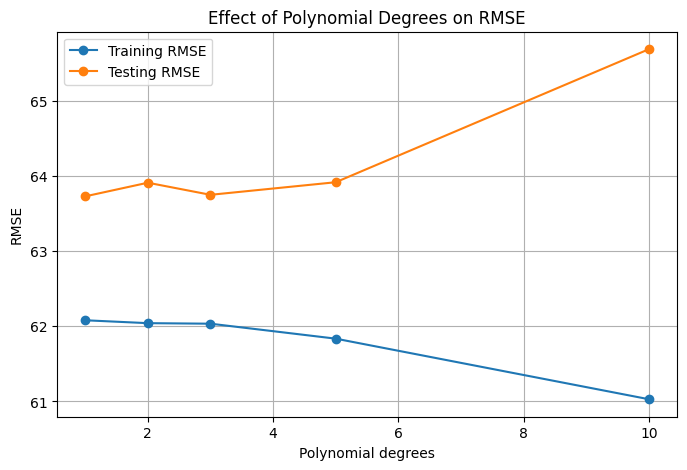

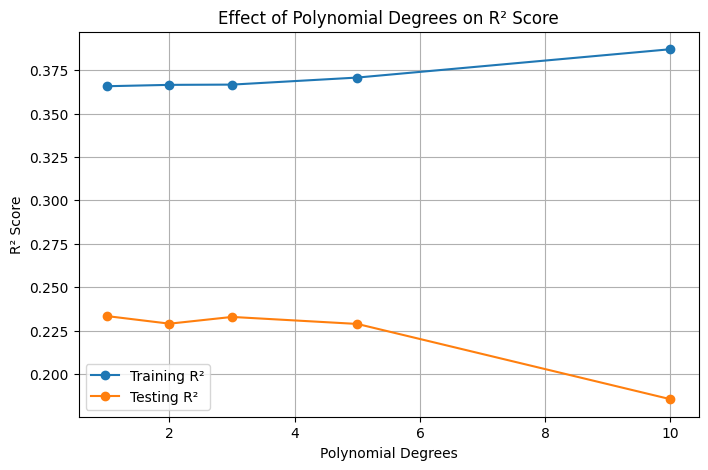

In [1]:

import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.datasets import load_diabetes

data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
print(df.head())

x = data.data[:, 2].reshape(-1, 1)
y = data.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
degrees = [1, 2, 3, 5, 10]
train_rmse = []
test_rmse = []
train_r2 = []
test_r2 = []
for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree),LinearRegression())
    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    train_error = np.sqrt( mean_squared_error(y_train, y_train_pred))
    test_error = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_score = r2_score(y_train, y_train_pred)
    test_score = r2_score(y_test, y_test_pred)
    train_rmse.append(train_error)
    test_rmse.append(test_error)
    train_r2.append(train_score)
    test_r2.append(test_score)
for i in range(len(degrees)):
    print("Polynomial degree:", degrees[i])
    print("Training RMSE:", round(train_rmse[i], 2))
    print("Testing RMSE:", round(test_rmse[i], 2))
    print("Training R²:", round(train_r2[i], 2))
    print("Testing R²:", round(test_r2[i], 2))
plt.figure(figsize=(8, 5))

plt.plot(degrees,
         train_rmse,
         marker="o",
         label="Training RMSE")

plt.plot(degrees,
         test_rmse,
         marker="o",
         label="Testing RMSE")

plt.xlabel("Polynomial degrees")
plt.ylabel("RMSE")
plt.title("Effect of Polynomial Degrees on RMSE")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))

plt.plot(
    degrees,
    train_r2,
    marker='o',
    label="Training R²"
)

plt.plot(
    degrees,
    test_r2,
    marker='o',
    label="Testing R²"
)

plt.xlabel("Polynomial Degrees")
plt.ylabel("R² Score")
plt.title("Effect of Polynomial Degrees on R² Score")
plt.legend()
plt.grid(True)
plt.show()

